<a href="https://colab.research.google.com/github/ayelefeleke/Superstore_pandas/blob/main/Superstore_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import library

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

To load the dataset,and the unicode is used to Prevents UnicodeDecodeError unicode is not used
pandas misreads character
Error occurs
Special symbols break

In [38]:
df = pd.read_csv("/content/Sample - Superstore.csv", encoding="latin1")

to show the first 5 rows of the data set

In [39]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


To see data set information

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

to see what datatypes

In [41]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


to see Mathematical statics like mean,median,std,max...

In [42]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


to check wether there is missing values

In [43]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [44]:
df.dropna(inplace=True)

In [45]:
df.fillna(method="ffill", inplace=True)

/tmp/ipykernel_11614/173857299.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


To Converts text dates into proper datetime format

In [46]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

to extract month and year

In [47]:
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

i'm create new feature called profit margin

In [48]:
df['Profit Margin'] = df['Profit'] / df['Sales']

In [49]:
df[['Sales', 'Profit', 'Profit Margin']].head()

,Sales,Profit,Profit Margin
0,261.9600,41.9136,0.1600
1,731.9400,219.5820,0.3000
2,14.6200,6.8714,0.4700
3,957.5775,-383.0310,-0.4000
4,22.3680,2.5164,0.1125


total sales by category

In [50]:
df.groupby('Category')['Sales'].sum()

,Sales
Category,
Furniture,741999.7953
Office Supplies,719047.0320
Technology,836154.0330


total profit by region

In [51]:
df.groupby('Region')['Profit'].sum()

,Profit
Region,
Central,39706.3625
East,91522.7800
South,46749.4303
West,108418.4489


here are the top 5 customer based on sales

In [52]:
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571


this is analysis of sales over time

In [53]:
df.groupby(['Year', 'Month'])['Sales'].sum()

Year  Month
2014  1         14236.8950
      2          4519.8920
      3         55691.0090
      4         28295.3450
      5         23648.2870
      6         34595.1276
      7         33946.3930
      8         27909.4685
      9         81777.3508
      10        31453.3930
      11        78628.7167
      12        69545.6205
2015  1         18174.0756
      2         11951.4110
      3         38726.2520
      4         34195.2085
      5         30131.6865
      6         24797.2920
      7         28765.3250
      8         36898.3322
      9         64595.9180
      10        31404.9235
      11        75972.5635
      12        74919.5212
2016  1         18542.4910
      2         22978.8150
      3         51715.8750
      4         38750.0390
      5         56987.7280
      6         40344.5340
      7         39261.9630
      8         31115.3743
      9         73410.0249
      10        59687.7450
      11        79411.9658
      12        96999.0430
2017  1         43971.3740
      2         20301.1334
      3         58872.3528
      4         36521.5361
      5         44261.1102
      6         52981.7257
      7         45264.4160
      8         63120.8880
      9         87866.6520
      10        77776.9232
      11       118447.8250
      12        83829.3188
Name: Sales, dtype: float64

sales by category and region

In [54]:
pd.pivot_table(df,
               values='Sales',
               index='Category',
               columns='Region',
               aggfunc='sum')

Region,Central,East,South,West
Category,,,,
Furniture,163797.1638,208291.204,117298.684,252612.7435
Office Supplies,167026.4150,205516.055,125651.313,220853.2490
Technology,170416.3120,264973.981,148771.908,251991.8320


sales by segment over time

In [55]:
pd.pivot_table(df,
               values='Sales',
               index='Month',
               columns='Segment',
               aggfunc='sum')

Segment,Consumer,Corporate,Home Office
Month,,,
1,50441.2906,26790.3480,17693.1970
2,33826.1760,14575.0670,11350.0084
3,89174.7070,58239.9132,57590.8686
4,54845.1895,49233.1636,33683.7755
5,86932.7144,47289.0323,20807.0650
6,82910.1803,40858.5370,28949.9620
7,81769.7730,46919.2060,18549.1180
8,82319.8063,57529.4477,19194.8090
9,185055.9196,74020.2213,48573.8048


profit of subcategory

In [56]:
pd.pivot_table(df,
          values='Profit',
               index='Sub-Category',
              aggfunc='sum')

,Profit
Sub-Category,
Accessories,41936.6357
Appliances,18138.0054
Art,6527.7870
Binders,30221.7633
Bookcases,-3472.5560
Chairs,26590.1663
Copiers,55617.8249
Envelopes,6964.1767
Fasteners,949.5182


to displit And merge data

to split

In [57]:
sales_df = df[['Order ID', 'Customer Name', 'Sales']]
profit_df = df[['Order ID', 'Profit']]

to merge

In [58]:
merged_df = pd.merge(sales_df, profit_df, on='Order ID')

let verify the merge

In [59]:
merged_df.head()

,Order ID,Customer Name,Sales,Profit
0,CA-2016-152156,Claire Gute,261.96,41.9136
1,CA-2016-152156,Claire Gute,261.96,219.5820
2,CA-2016-152156,Claire Gute,731.94,41.9136
3,CA-2016-152156,Claire Gute,731.94,219.5820
4,CA-2016-138688,Darrin Van Huff,14.62,6.8714


sales trend over time that is line chart

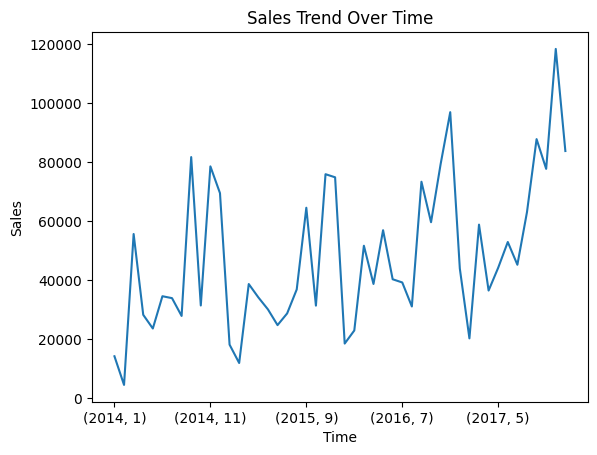

In [60]:
df.groupby(['Year','Month'])['Sales'].sum().plot(kind='line')
plt.title("Sales Trend Over Time")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.show()

sales by category this is barchart

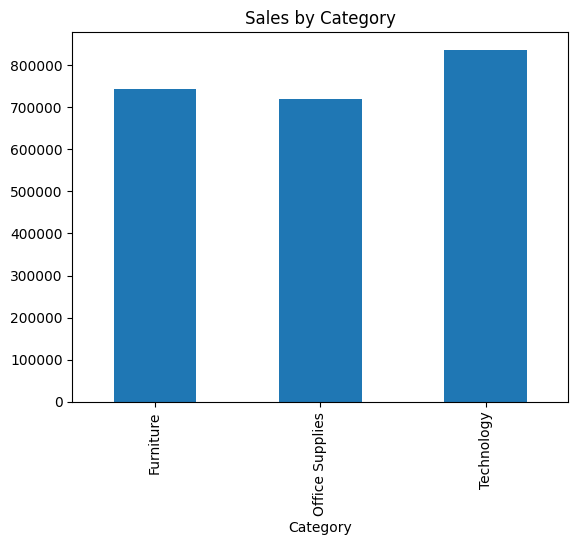

In [61]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()

profit by region by bar chart

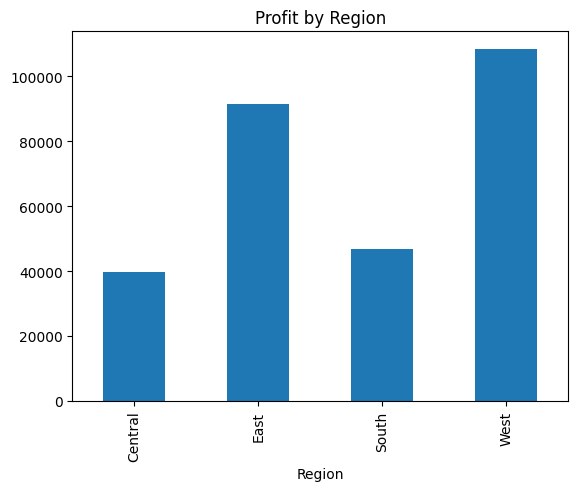

In [62]:
df.groupby('Region')['Profit'].sum().plot(kind='bar')
plt.title("Profit by Region")
plt.show()

pie chart segment distribution

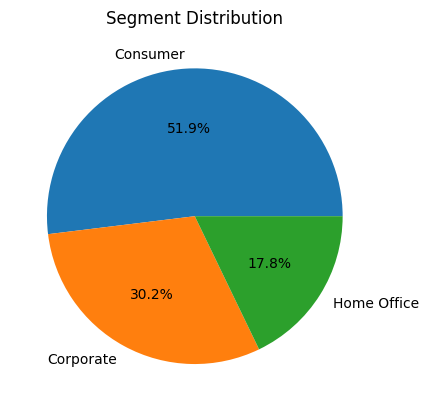

In [63]:
df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Segment Distribution")
plt.ylabel("")
plt.show()

most profitable category is

In [64]:
df.groupby('Category')['Profit'].sum().idxmax()

'Technology'

the list performing regioin is

In [65]:
df.groupby('Region')['Profit'].sum().idxmin()

'Central'

let correlate relation between sales and profit

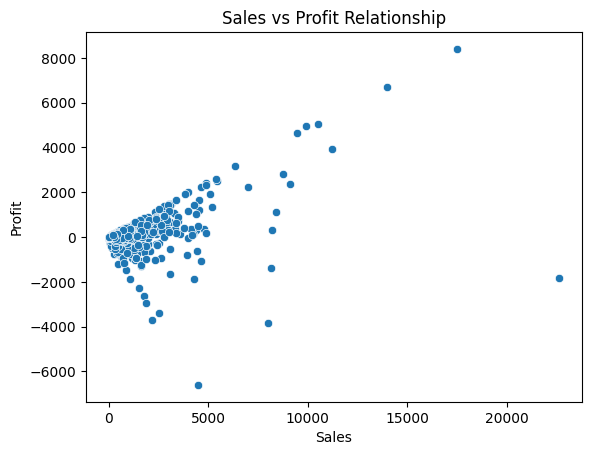

In [66]:
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit Relationship")
plt.show()

this is trend overtime

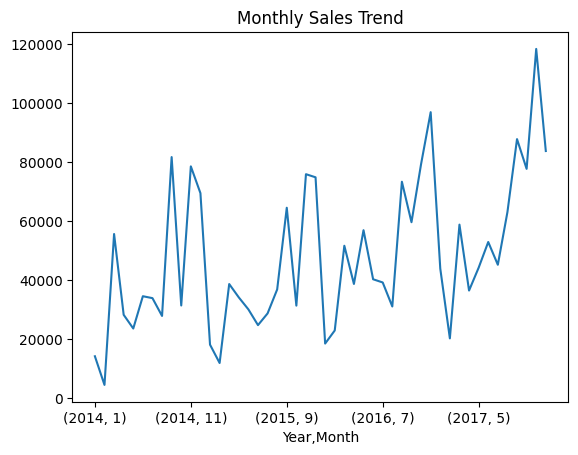

In [67]:
df.groupby(['Year','Month'])['Sales'].sum().plot()
plt.title("Monthly Sales Trend")
plt.show()